
# Deep Reinforcement Learning — Module 5 Tutorial  
## Multi-Agent Reinforcement Learning (MARL)

This notebook is a **hands-on tutorial** for the lecture on **Multi-Agent Reinforcement Learning**. It is designed so that you can:
- revisit the main concepts from the lecture,
- run small MARL experiments with **minimal dependencies**,
- observe **coordination**, **non-stationarity**, and **credit assignment** in code,
- practice reasoning about **CTDE**, **VDN/QMIX intuition**, and **counterfactual advantage**.

This notebook uses **toy environments** so that the core ideas stay visible. The goal is **conceptual understanding**, not benchmark performance.

---

## Learning goals

By the end of this notebook, you should be able to:

1. explain why MARL is harder than single-agent RL,
2. run **independent learners** in a small cooperative setting,
3. observe how a changing partner induces **non-stationarity**,
4. understand when a **value decomposition** idea can or cannot fit a team reward,
5. compute a simple **counterfactual advantage** signal,
6. propose sensible evaluation criteria for MARL experiments.

---

## How to use this notebook

A good workflow is:

1. **Read** the markdown cell of each section.
2. **Run** the code cells.
3. **Answer** the exercise questions in your own words.
4. **Modify** the code where marked and observe how the results change.

The notebook is fully runnable as provided, but several sections ask you to change hyperparameters, reward tables, or policies and interpret the outcome.



## 1. Quick recap: what changes in MARL?

In single-agent RL, the environment transition law is usually assumed fixed while the agent learns.

In MARL, each agent learns while other agents also adapt. From one agent's viewpoint, the environment can therefore become **non-stationary**.

A common formalization is a **Markov game** (also called a stochastic game), which extends an MDP:

\[
\big(\mathcal{S}, \{\mathcal{O}_i\}_{i=1}^N, \{\mathcal{A}_i\}_{i=1}^N, P, \{r_i\}_{i=1}^N, \gamma \big)
\]

where:
- \(s_t \in \mathcal{S}\) is the global state,
- \(o_t^i \in \mathcal{O}_i\) is agent \(i\)'s local observation,
- \(a_t^i \in \mathcal{A}_i\) is agent \(i\)'s action,
- \(\mathbf{a}_t = (a_t^1,\dots,a_t^N)\) is the **joint action**,
- \(P(s_{t+1}\mid s_t,\mathbf{a}_t)\) is the transition rule,
- \(r_t^i\) is the reward of agent \(i\),
- \(\gamma\) is the discount factor.

### Common MARL settings
- **Cooperative:** agents share the same team objective.
- **Competitive / zero-sum:** one agent's gain is another's loss.
- **Mixed:** some incentives are shared, others are conflicting.

### A central idea from the lecture: CTDE
**Centralized Training with Decentralized Execution (CTDE)** means:

- during **training**, we may use extra global information such as the full state, all actions, or team reward;
- during **execution**, each agent must act only from its own local observation.

This notebook starts with the simplest possible toy games to make these ideas concrete.


In [1]:

import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (7, 4)
plt.rcParams["axes.grid"] = True

def moving_average(x, window=25):
    x = np.asarray(x, dtype=float)
    if window <= 1:
        return x.copy()
    if len(x) < window:
        return np.full_like(x, np.mean(x), dtype=float)
    kernel = np.ones(window) / window
    y = np.convolve(x, kernel, mode="valid")
    prefix = np.full(window - 1, y[0])
    return np.concatenate([prefix, y])

def plot_matrix(matrix, title, xlabel="Agent 2 action", ylabel="Agent 1 action", cmap="viridis"):
    fig, ax = plt.subplots(figsize=(5.2, 4.2))
    im = ax.imshow(matrix, cmap=cmap)
    ax.set_xticks(range(matrix.shape[1]))
    ax.set_yticks(range(matrix.shape[0]))
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    for i in range(matrix.shape[0]):
        for j in range(matrix.shape[1]):
            ax.text(j, i, f"{matrix[i, j]:.2f}", ha="center", va="center", color="white" if matrix[i, j] < matrix.max()/2 else "black")
    fig.colorbar(im, ax=ax)
    plt.show()



## 2. Exercise 1 — A cooperative matrix game

We begin with a repeated **two-agent cooperative matrix game**. There is only one state, so the entire problem is about choosing a good **joint action**.

Let each agent have two actions: \(0\) and \(1\).  
The team reward matrix is:

\[
R(a^1, a^2) =
\begin{bmatrix}
8 & 0 \\
0 & 5
\end{bmatrix}
\]

Interpretation:
- if both agents choose action \(0\), the team gets reward \(8\),
- if both choose action \(1\), the team gets reward \(5\),
- if they mismatch, the team gets reward \(0\).

This game is useful because:
- it is **cooperative**,
- it requires **coordination**,
- it exhibits a simple form of **multi-agent credit assignment**.

Even though the best joint action is obvious if we see the full matrix, decentralized learners may still struggle to coordinate on it.


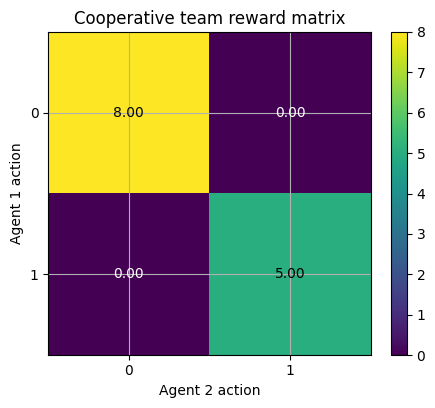

Best joint action index (agent1, agent2): (np.int64(0), np.int64(0))
Best team reward: 8.0


In [2]:

R_coop = np.array([
    [8.0, 0.0],
    [0.0, 5.0]
])

plot_matrix(R_coop, "Cooperative team reward matrix")
print("Best joint action index (agent1, agent2):", np.unravel_index(np.argmax(R_coop), R_coop.shape))
print("Best team reward:", R_coop.max())



### Questions
1. Why is this a **cooperative** game?
2. Why can this still be hard for independent learners?
3. If the agents only observe the shared team reward, what ambiguity remains about **who contributed what**?
4. Which issue is already visible here: **coordination**, **credit assignment**, or **non-stationarity**?  
   Answer: in fact, all three can appear, but explain which one is most immediate.



## 3. Exercise 2 — Independent Q-learning on the cooperative game

Now we train two **independent learners**.  
Each agent keeps its own scalar action values:

\[
Q_i(a_i), \quad i \in \{1,2\}
\]

Since this toy game has only one repeated state, we can ignore state notation and update each selected action by a simple bandit-style TD step:

\[
Q_i(a_i) \leftarrow Q_i(a_i) + \alpha\big(r - Q_i(a_i)\big)
\]

where:
- \(r\) is the shared team reward,
- \(\alpha\) is the learning rate.

Each agent uses an \(\varepsilon\)-greedy policy:
- with probability \(\varepsilon\), it explores,
- otherwise it selects the action with the largest current \(Q_i\).

This is **not** CTDE. It is the simplest decentralized baseline: two agents learning independently from the same team reward.


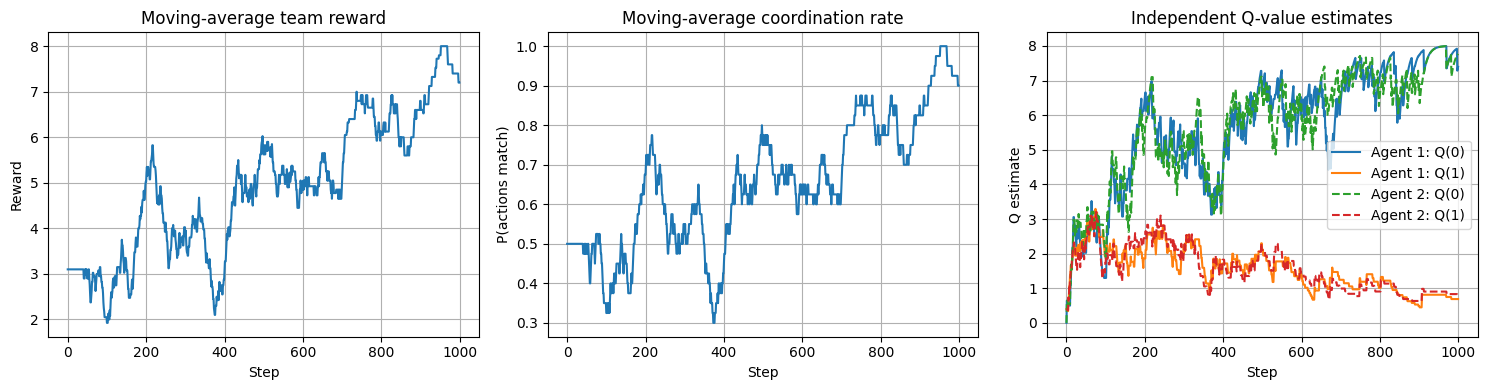

Final Q-values
Agent 1: [7.39569884 0.68795771]
Agent 2: [7.76879809 0.76507388]


In [3]:

def epsilon_greedy(q_values, epsilon, rng):
    if rng.random() < epsilon:
        return int(rng.integers(len(q_values)))
    max_value = np.max(q_values)
    greedy_actions = np.flatnonzero(np.isclose(q_values, max_value))
    return int(rng.choice(greedy_actions))

def run_independent_q_learning(
    payoff_matrix,
    steps=800,
    alpha=0.08,
    eps_start=1.0,
    eps_end=0.05,
    seed=0
):
    rng = np.random.default_rng(seed)
    n_actions = payoff_matrix.shape[0]

    q1 = np.zeros(n_actions)
    q2 = np.zeros(n_actions)

    rewards = []
    coord = []
    actions1 = []
    actions2 = []
    q1_hist = []
    q2_hist = []

    for t in range(steps):
        frac = t / max(steps - 1, 1)
        epsilon = eps_start + frac * (eps_end - eps_start)

        a1 = epsilon_greedy(q1, epsilon, rng)
        a2 = epsilon_greedy(q2, epsilon, rng)
        r = payoff_matrix[a1, a2]

        q1[a1] += alpha * (r - q1[a1])
        q2[a2] += alpha * (r - q2[a2])

        rewards.append(r)
        coord.append(float(a1 == a2))
        actions1.append(a1)
        actions2.append(a2)
        q1_hist.append(q1.copy())
        q2_hist.append(q2.copy())

    return {
        "rewards": np.array(rewards),
        "coord": np.array(coord),
        "actions1": np.array(actions1),
        "actions2": np.array(actions2),
        "q1_hist": np.array(q1_hist),
        "q2_hist": np.array(q2_hist),
        "q1_final": q1,
        "q2_final": q2,
    }

result = run_independent_q_learning(R_coop, steps=1000, alpha=0.08, seed=7)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].plot(moving_average(result["rewards"], 40))
axes[0].set_title("Moving-average team reward")
axes[0].set_xlabel("Step")
axes[0].set_ylabel("Reward")

axes[1].plot(moving_average(result["coord"], 40))
axes[1].set_title("Moving-average coordination rate")
axes[1].set_xlabel("Step")
axes[1].set_ylabel("P(actions match)")

axes[2].plot(result["q1_hist"][:, 0], label="Agent 1: Q(0)")
axes[2].plot(result["q1_hist"][:, 1], label="Agent 1: Q(1)")
axes[2].plot(result["q2_hist"][:, 0], "--", label="Agent 2: Q(0)")
axes[2].plot(result["q2_hist"][:, 1], "--", label="Agent 2: Q(1)")
axes[2].set_title("Independent Q-value estimates")
axes[2].set_xlabel("Step")
axes[2].set_ylabel("Q estimate")
axes[2].legend()

plt.tight_layout()
plt.show()

print("Final Q-values")
print("Agent 1:", result["q1_final"])
print("Agent 2:", result["q2_final"])



### Repeat over multiple seeds

A single MARL run can be misleading. Let us average across several seeds to see whether the behavior is robust.


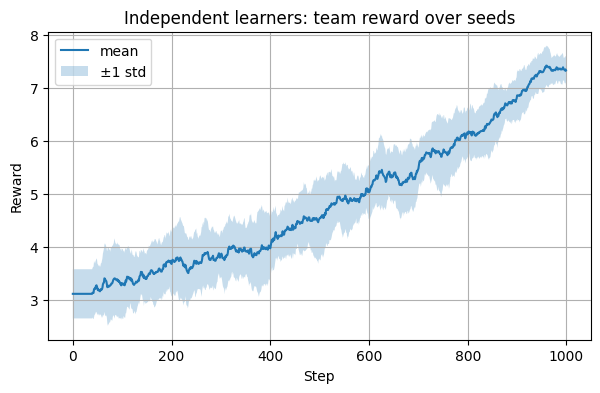

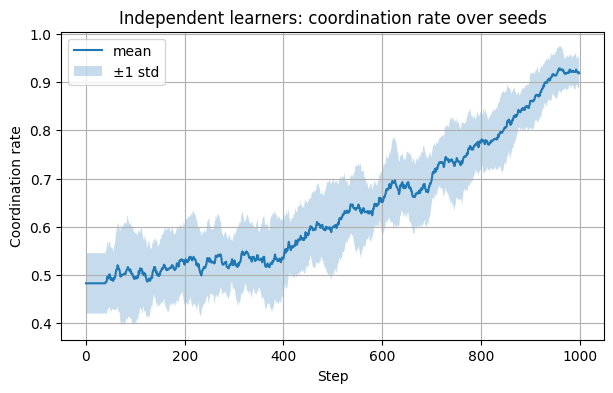

In [4]:

seeds = range(20)
all_rewards = []
all_coord = []

for seed in seeds:
    res = run_independent_q_learning(R_coop, steps=1000, alpha=0.08, seed=seed)
    all_rewards.append(moving_average(res["rewards"], 40))
    all_coord.append(moving_average(res["coord"], 40))

all_rewards = np.array(all_rewards)
all_coord = np.array(all_coord)

def plot_mean_std(array, title, ylabel):
    mean = array.mean(axis=0)
    std = array.std(axis=0)
    x = np.arange(len(mean))
    plt.figure(figsize=(7, 4))
    plt.plot(x, mean, label="mean")
    plt.fill_between(x, mean - std, mean + std, alpha=0.25, label="±1 std")
    plt.title(title)
    plt.xlabel("Step")
    plt.ylabel(ylabel)
    plt.legend()
    plt.show()

plot_mean_std(all_rewards, "Independent learners: team reward over seeds", "Reward")
plot_mean_std(all_coord, "Independent learners: coordination rate over seeds", "Coordination rate")



### Questions
1. Did the agents always converge to the globally best joint action \((0,0)\)?
2. Why might they sometimes settle on the **suboptimal but coordinated** joint action \((1,1)\)?
3. Why is a shared team reward sometimes insufficient for efficient decentralized learning?
4. How would you expect this difficulty to scale when:
   - the number of agents grows,
   - the number of actions per agent grows,
   - the reward becomes sparse?

### Try it yourself
Change one or more of the following and rerun the section:
- learning rate `alpha`,
- exploration schedule `eps_start`, `eps_end`,
- number of steps,
- reward matrix values.

Then answer: which changes helped coordination, and which made it less stable?



## 4. Exercise 3 — Non-stationarity from a changing partner

One of the most important differences between single-agent RL and MARL is **non-stationarity**.

Here we isolate that effect. Agent 1 learns against a partner whose behavior changes halfway through training.

- In the first half, Agent 2 strongly prefers action \(0\).
- In the second half, Agent 2 strongly prefers action \(1\).

From Agent 1's perspective, the reward distribution associated with each action changes over time.  
This violates the usual stationary-environment assumption.


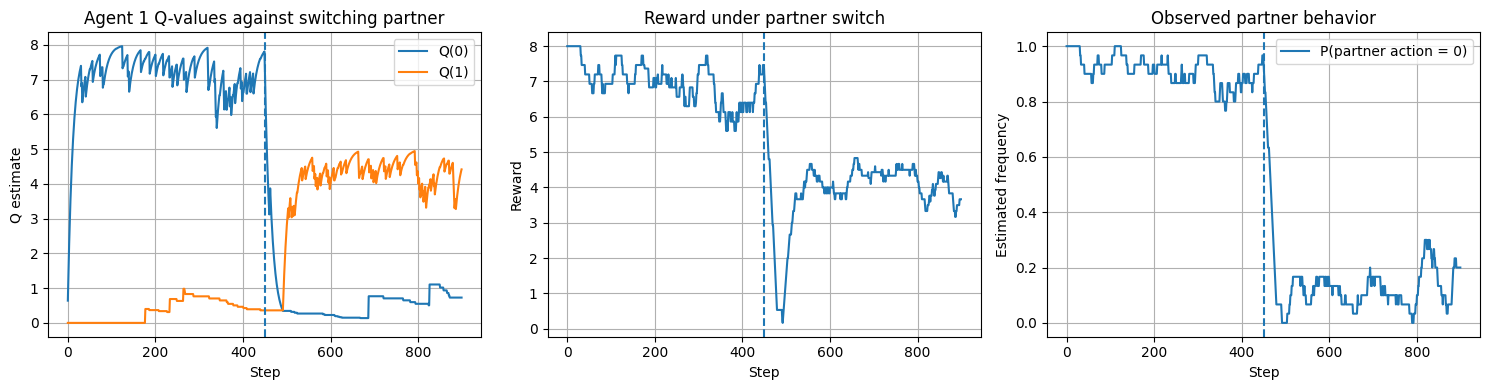

In [5]:

def run_against_switching_partner(
    payoff_matrix,
    steps=800,
    alpha=0.08,
    epsilon=0.1,
    p_first=0.9,
    p_second=0.1,
    seed=0
):
    rng = np.random.default_rng(seed)
    q = np.zeros(payoff_matrix.shape[0])

    rewards = []
    q_hist = []
    partner_actions = []

    for t in range(steps):
        a1 = epsilon_greedy(q, epsilon, rng)

        p_action0 = p_first if t < steps // 2 else p_second
        a2 = 0 if rng.random() < p_action0 else 1

        r = payoff_matrix[a1, a2]
        q[a1] += alpha * (r - q[a1])

        rewards.append(r)
        q_hist.append(q.copy())
        partner_actions.append(a2)

    return np.array(rewards), np.array(q_hist), np.array(partner_actions)

rewards_ns, q_hist_ns, partner_actions_ns = run_against_switching_partner(
    R_coop, steps=900, alpha=0.08, epsilon=0.1, seed=3
)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(q_hist_ns[:, 0], label="Q(0)")
axes[0].plot(q_hist_ns[:, 1], label="Q(1)")
axes[0].axvline(len(q_hist_ns)//2, linestyle="--")
axes[0].set_title("Agent 1 Q-values against switching partner")
axes[0].set_xlabel("Step")
axes[0].set_ylabel("Q estimate")
axes[0].legend()

axes[1].plot(moving_average(rewards_ns, 30))
axes[1].axvline(len(q_hist_ns)//2, linestyle="--")
axes[1].set_title("Reward under partner switch")
axes[1].set_xlabel("Step")
axes[1].set_ylabel("Reward")

axes[2].plot(moving_average((partner_actions_ns == 0).astype(float), 30), label="P(partner action = 0)")
axes[2].axvline(len(q_hist_ns)//2, linestyle="--")
axes[2].set_title("Observed partner behavior")
axes[2].set_xlabel("Step")
axes[2].set_ylabel("Estimated frequency")
axes[2].legend()

plt.tight_layout()
plt.show()



### Questions
1. Why do Agent 1's Q-values drift after the partner changes policy?
2. In a true multi-agent setting, if **both** agents update simultaneously, why is the problem even harder?
3. Why can replay buffers become delicate in MARL when the policy distribution of teammates or opponents changes over time?
4. Which lecture concept does this section illustrate most directly?  
   **Answer:** non-stationarity.

### Extension
Modify the code so that the partner changes **gradually** instead of abruptly.  
Then compare the resulting Q-value drift.



## 5. Exercise 4 — CTDE and value decomposition intuition

In cooperative MARL, a common idea is:

- train with extra global information,
- execute with decentralized policies.

One important family is **value decomposition**, where a centralized team value is built from per-agent utilities.

A simple VDN-style idea is:

\[
Q_{\text{tot}}(\mathbf{a}) \approx Q_1(a^1) + Q_2(a^2)
\]

This can work well if the team reward structure is close to additive.  
But it can struggle when there is strong **interaction** or **synergy** between agents.

We now compare two games:
1. an **additive** team reward table,
2. a **synergy** table where the best joint action depends on interaction, not just separate per-agent contributions.


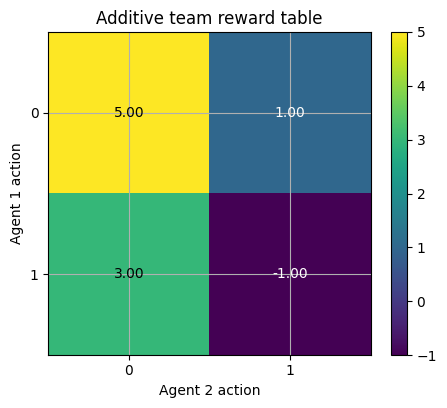

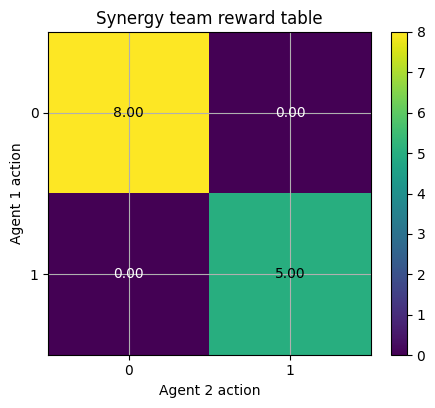

In [6]:

R_additive = np.array([
    [5.0, 1.0],
    [3.0, -1.0]
])

R_synergy = np.array([
    [8.0, 0.0],
    [0.0, 5.0]
])

plot_matrix(R_additive, "Additive team reward table")
plot_matrix(R_synergy, "Synergy team reward table")


In [7]:

def fit_vdn_like(payoff):
    # Fit payoff[a1, a2] ≈ q1[a1] + q2[a2] in least-squares sense.
    rows = []
    targets = []
    n_actions_1, n_actions_2 = payoff.shape

    for a1 in range(n_actions_1):
        for a2 in range(n_actions_2):
            row = np.zeros(n_actions_1 + n_actions_2)
            row[a1] = 1.0
            row[n_actions_1 + a2] = 1.0
            rows.append(row)
            targets.append(payoff[a1, a2])

    A = np.vstack(rows)
    b = np.array(targets)
    x, *_ = np.linalg.lstsq(A, b, rcond=None)

    q1 = x[:n_actions_1]
    q2 = x[n_actions_1:]
    recon = q1[:, None] + q2[None, :]
    mse = np.mean((payoff - recon) ** 2)

    return q1, q2, recon, mse

for name, table in [("Additive", R_additive), ("Synergy", R_synergy)]:
    q1, q2, recon, mse = fit_vdn_like(table)
    print(f"=== {name} table ===")
    print("Recovered q1:", np.round(q1, 3))
    print("Recovered q2:", np.round(q2, 3))
    print("Reconstruction MSE:", round(float(mse), 6))
    print("Original table:\n", table)
    print("Reconstructed table:\n", np.round(recon, 3))
    print()


=== Additive table ===
Recovered q1: [2. 0.]
Recovered q2: [ 3. -1.]
Reconstruction MSE: 0.0
Original table:
 [[ 5.  1.]
 [ 3. -1.]]
Reconstructed table:
 [[ 5.  1.]
 [ 3. -1.]]

=== Synergy table ===
Recovered q1: [2.375 0.875]
Recovered q2: [2.375 0.875]
Reconstruction MSE: 10.5625
Original table:
 [[8. 0.]
 [0. 5.]]
Reconstructed table:
 [[4.75 3.25]
 [3.25 1.75]]



/tmp/ipykernel_3257/3373558978.py:20: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


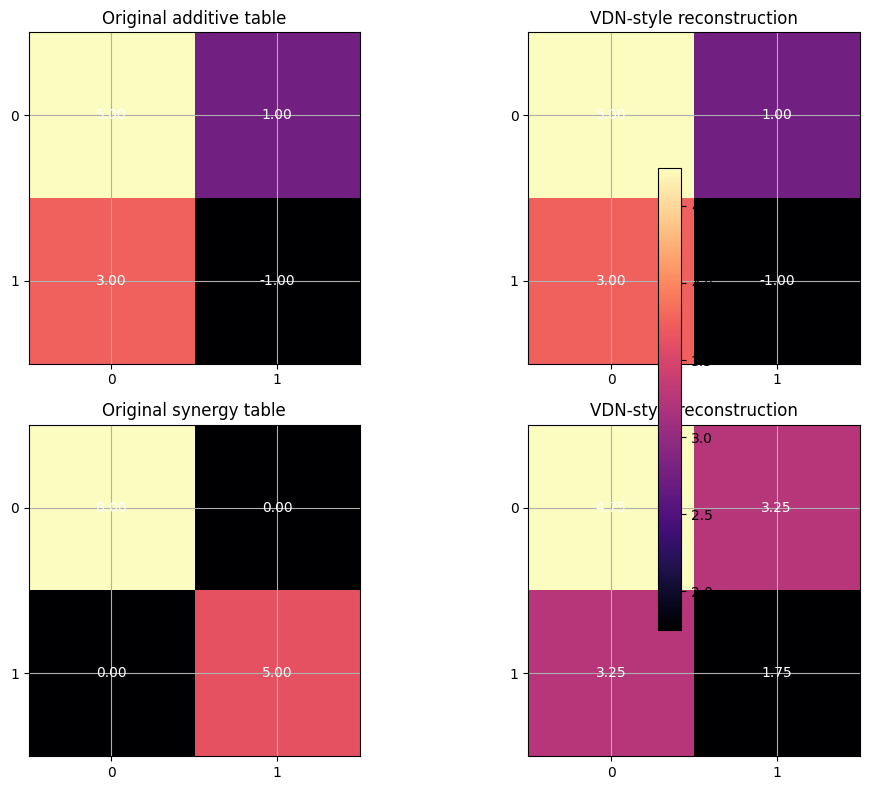

In [8]:

fig, axes = plt.subplots(2, 2, figsize=(10, 8))

_, _, recon_add, _ = fit_vdn_like(R_additive)
_, _, recon_syn, _ = fit_vdn_like(R_synergy)

for ax, matrix, title in [
    (axes[0, 0], R_additive, "Original additive table"),
    (axes[0, 1], recon_add, "VDN-style reconstruction"),
    (axes[1, 0], R_synergy, "Original synergy table"),
    (axes[1, 1], recon_syn, "VDN-style reconstruction"),
]:
    im = ax.imshow(matrix, cmap="magma")
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_title(title)
    for i in range(matrix.shape[0]):
        for j in range(matrix.shape[1]):
            ax.text(j, i, f"{matrix[i, j]:.2f}", ha="center", va="center", color="white")
fig.colorbar(im, ax=axes.ravel().tolist(), shrink=0.75)
plt.tight_layout()
plt.show()



### Interpretation

- In the **additive** case, a decomposition of the form \(Q_{\text{tot}} \approx Q_1 + Q_2\) can match the team reward structure well.
- In the **synergy** case, the joint reward depends strongly on the combination itself.  
  Then a purely additive decomposition is no longer expressive enough.

This is one reason why more expressive mixing methods such as **QMIX** were proposed.  
QMIX still mixes per-agent values, but does so through a constrained **monotonic mixing network** rather than a plain sum.

### Questions
1. Which table is easier for a VDN-style decomposition to fit, and why?
2. Why is the synergy table harder?
3. What is the intuition behind moving from **VDN** to **QMIX**?
4. Why is this naturally associated with **centralized training**?

### Try it yourself
Replace `R_synergy` by one of the following and rerun:
- anti-coordination: `[[0, 4], [4, 0]]`
- weak synergy: `[[6, 1], [1, 5]]`
- your own 2×2 cooperative game

Then inspect whether the additive decomposition error becomes larger or smaller.



## 6. Exercise 5 — Counterfactual advantage intuition (COMA-style idea)

A major problem in cooperative MARL is **multi-agent credit assignment**.

Suppose the team receives a good reward.  
Was it because Agent 1 acted well, Agent 2 acted well, or both?

A counterfactual baseline addresses this by asking:

> How good was Agent \(i\)'s chosen action compared with what would have happened if only Agent \(i\) had acted differently, while the other agents' actions stayed fixed?

A simple COMA-style counterfactual advantage for Agent 1 is:

\[
A^1(s, a^1, a^2)
=
Q(s, a^1, a^2)
-
\sum_{\tilde a^1} \pi_1(\tilde a^1 \mid o^1)\, Q(s, \tilde a^1, a^2)
\]

The second term is the **counterfactual baseline**:
- keep Agent 2's action fixed,
- average over Agent 1's possible actions under its current policy.

If the advantage is positive, Agent 1's sampled action was better than its own average alternative.


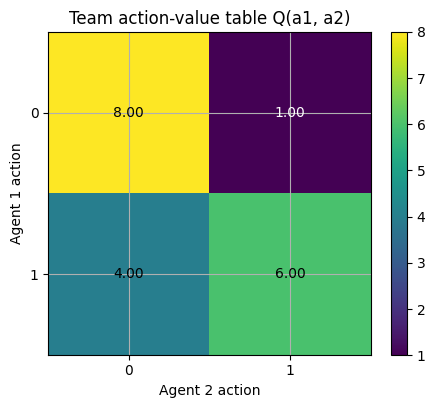

Agent 1 policy: [0.7 0.3]
Fixed Agent 2 action: 1
Taken Agent 1 action: 0
Counterfactual baseline for Agent 1: 2.5
Counterfactual advantage for Agent 1: -1.5


In [9]:

Q_team = np.array([
    [8.0, 1.0],
    [4.0, 6.0]
])

pi_agent1 = np.array([0.7, 0.3])  # Agent 1's current policy over actions 0 and 1
a1_taken = 0
a2_fixed = 1

baseline_agent1 = np.sum(pi_agent1 * Q_team[:, a2_fixed])
advantage_agent1 = Q_team[a1_taken, a2_fixed] - baseline_agent1

plot_matrix(Q_team, "Team action-value table Q(a1, a2)")

print("Agent 1 policy:", pi_agent1)
print("Fixed Agent 2 action:", a2_fixed)
print("Taken Agent 1 action:", a1_taken)
print("Counterfactual baseline for Agent 1:", round(float(baseline_agent1), 4))
print("Counterfactual advantage for Agent 1:", round(float(advantage_agent1), 4))



### Questions
1. Is Agent 1's selected action better or worse than its own policy-average alternative?
2. Why is this more informative than using only the team reward?
3. How does this help with **credit assignment**?
4. In larger problems, why might we need a centralized critic \(Q(s,\mathbf{a})\) to build such signals?

### Try it yourself
Change:
- `pi_agent1`,
- `a1_taken`,
- `a2_fixed`,
- or the table `Q_team`.

Then recompute the counterfactual baseline and interpret the sign of the advantage.



## 7. Exercise 6 — Optional extension: parameter sharing

In many cooperative settings, agents are homogeneous or nearly homogeneous.  
A common engineering simplification is **parameter sharing**:

\[
\pi_1 = \pi_2 = \cdots = \pi_N
\]

or similarly for a value function.

This means:
- all agents use the **same network parameters**,
- but each agent still acts on its own local observation,
- experience from several agents can update one shared model.

Below is a simple experiment where both agents share the **same** Q-values in the cooperative game.  
This is not always appropriate, but it is worth comparing against independent learning.


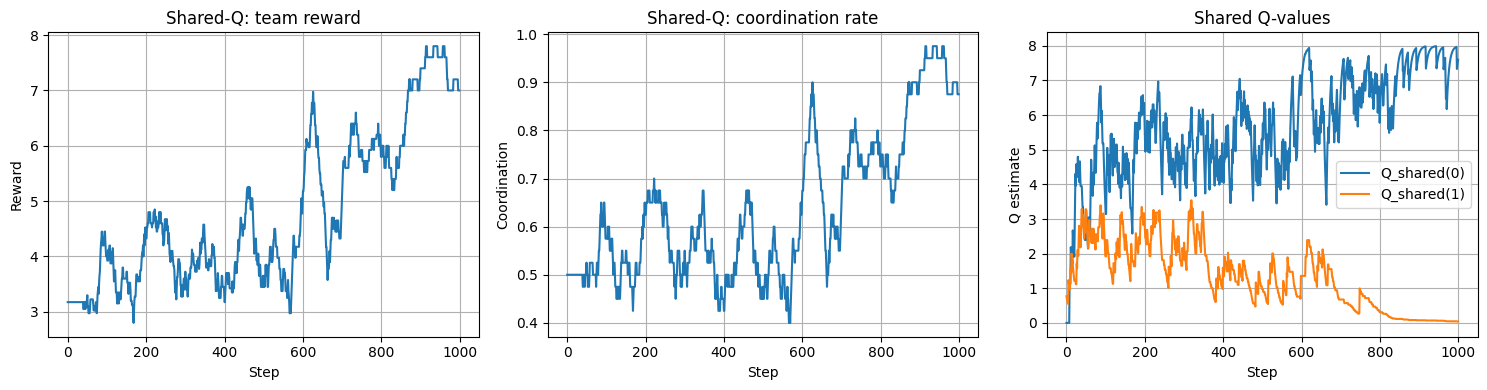

Final shared Q-values: [7.59618535 0.04190956]


In [10]:

def run_shared_q_learning(
    payoff_matrix,
    steps=800,
    alpha=0.08,
    eps_start=1.0,
    eps_end=0.05,
    seed=0
):
    rng = np.random.default_rng(seed)
    q_shared = np.zeros(payoff_matrix.shape[0])

    rewards = []
    coord = []
    q_hist = []

    for t in range(steps):
        frac = t / max(steps - 1, 1)
        epsilon = eps_start + frac * (eps_end - eps_start)

        a1 = epsilon_greedy(q_shared, epsilon, rng)
        a2 = epsilon_greedy(q_shared, epsilon, rng)

        r = payoff_matrix[a1, a2]

        q_shared[a1] += alpha * (r - q_shared[a1])
        q_shared[a2] += alpha * (r - q_shared[a2])

        rewards.append(r)
        coord.append(float(a1 == a2))
        q_hist.append(q_shared.copy())

    return np.array(rewards), np.array(coord), np.array(q_hist), q_shared

rewards_shared, coord_shared, q_hist_shared, q_final_shared = run_shared_q_learning(R_coop, steps=1000, seed=4)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].plot(moving_average(rewards_shared, 40))
axes[0].set_title("Shared-Q: team reward")
axes[0].set_xlabel("Step")
axes[0].set_ylabel("Reward")

axes[1].plot(moving_average(coord_shared, 40))
axes[1].set_title("Shared-Q: coordination rate")
axes[1].set_xlabel("Step")
axes[1].set_ylabel("Coordination")

axes[2].plot(q_hist_shared[:, 0], label="Q_shared(0)")
axes[2].plot(q_hist_shared[:, 1], label="Q_shared(1)")
axes[2].set_title("Shared Q-values")
axes[2].set_xlabel("Step")
axes[2].set_ylabel("Q estimate")
axes[2].legend()

plt.tight_layout()
plt.show()

print("Final shared Q-values:", q_final_shared)



### Questions
1. When can parameter sharing be a good idea?
2. When can parameter sharing be a bad idea?
3. Compare this result with independent learners. Which one coordinated faster here?
4. Why does parameter sharing not solve all MARL difficulties?

---

## 8. Mini-project style exercises

Below are suggested follow-up exercises after you finish the notebook.

### A. Coordination variant
Change the team reward to an **anti-coordination** game:

\[
R =
\begin{bmatrix}
0 & 4 \\
4 & 0
\end{bmatrix}
\]

Tasks:
1. rerun independent learners,
2. rerun shared-parameter learners,
3. explain which setup finds a good convention more reliably.

### B. Robustness across seeds
For one experiment of your choice:
1. run at least **20 random seeds**,
2. report mean and standard deviation,
3. explain why one good-looking seed is not enough in MARL.

### C. Partner generalization
Train one agent with one fixed partner policy, then evaluate it against a **different** partner policy.  
Question: did the policy overfit to the training partner?

### D. Simple centralized critic idea
Create a table \(Q(a^1,a^2)\) and compute:
- a global team value,
- an additive decomposition,
- a counterfactual advantage.

Then explain which signal would be most useful for:
- team optimization,
- decentralized action selection,
- credit assignment.

### E. Application mapping
Model one engineering problem as a MARL problem, for example:
- wireless channel selection by multiple nodes,
- multi-intersection traffic control,
- robot formation control,
- cooperative resource allocation.

For your application, define:
- agents,
- local observations,
- actions,
- team vs individual rewards,
- why CTDE may be useful.



## 9. Concept check

Before leaving the notebook, make sure you can answer these briefly and precisely.

1. Why does MARL create **non-stationarity**?
2. What is the difference between **centralized training** and **decentralized execution**?
3. Why can a team reward create a **credit assignment** problem?
4. What is the intuition of **value decomposition**?
5. Why might VDN fail on strongly interacting team rewards?
6. What does a **counterfactual baseline** try to isolate?
7. Why are **multiple seeds** and **partner/opponent protocols** essential in MARL evaluation?



## 10. Summary

This notebook covered four core MARL ideas in a runnable form:

- **Coordination:** even a tiny cooperative game can be hard for independent learners.
- **Non-stationarity:** a changing partner changes the learning target itself.
- **CTDE / value factorization:** centralized team structure can guide decentralized policies.
- **Credit assignment:** counterfactual reasoning helps determine which agent's action mattered.

These are exactly the conceptual reasons why MARL algorithms differ from single-agent DQN, DDPG, or PPO.

---

## Suggested next step

A useful next coding step after this notebook is to implement one of the following:
- a tiny **independent Q-learning** gridworld with two agents,
- a toy **VDN** learner on a cooperative matrix game,
- a small **self-play** setup in a competitive game,
- or a simple **MAPPO-style** centralized critic for a discrete cooperative environment.

End of tutorial.
